In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
from src.parsing.treesitter_parser import parse_code
import pandas as pd

train_df = pd.read_parquet("../data/task_a/train.parquet")
val_df = pd.read_parquet("../data/task_a/val.parquet")

sample_code = train_df.iloc[0]["code"]
sample_lang = train_df.iloc[0]["language"]

tree = parse_code(sample_code, sample_lang)

print(tree.root_node)

<Node type=module, start_point=(0, 0), end_point=(13, 0)>


#### Feature Extractor

In [4]:
from collections import Counter
import numpy as np
import math


def extract_ast_features(code, language):

    tree = parse_code(code, language)

    if tree is None:
        return [0]*15

    nodes = []
    depths = []
    children_counts = []

    def traverse(node, depth=0):
        nodes.append(node.type)
        depths.append(depth)
        children_counts.append(len(node.children))

        for child in node.children:
            traverse(child, depth + 1)

    traverse(tree.root_node)

    total_nodes = len(nodes)
    leaf_nodes = sum(1 for c in children_counts if c == 0)

    if total_nodes == 0:
        return [0]*15

    max_depth = max(depths)
    avg_depth = np.mean(depths)
    depth_var = np.var(depths)

    avg_branch = np.mean(children_counts)
    max_children = max(children_counts)

    node_counter = Counter(nodes)
    unique_types = len(node_counter)

    probs = [v/total_nodes for v in node_counter.values()]
    entropy = -sum(p*math.log(p+1e-9) for p in probs)

    decision_nodes = sum(1 for n in nodes if n in ["if_statement","for_statement","while_statement"])
    cyclomatic = decision_nodes + 1

    function_calls = sum(1 for n in nodes if "call" in n)
    unique_calls = len([n for n in node_counter if "call" in n])

    leaf_ratio = leaf_nodes / total_nodes

    return [
        max_depth,
        avg_depth,
        depth_var,
        total_nodes,
        leaf_nodes,
        leaf_ratio,
        avg_branch,
        max_children,
        cyclomatic,
        decision_nodes,
        unique_types,
        entropy,
        function_calls,
        unique_calls,
        total_nodes - leaf_nodes
    ]

#### Test first on 100 samples.

In [5]:
sample_df = train_df.head(100)

features = sample_df.apply(
    lambda row: extract_ast_features(row["code"], row["language"]),
    axis=1
)

feature_df = pd.DataFrame(features.tolist())
feature_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,9,5.094118,3.532318,170,113,0.664706,0.994118,9,3,2,39,3.238338,5,1,57
1,30,10.094371,66.701359,1208,972,0.804636,0.999172,46,2,1,57,2.166643,9,1,236
2,9,5.581395,3.871282,215,144,0.669767,0.995349,11,2,1,41,3.186976,11,1,71
3,13,6.617143,8.327706,175,111,0.634286,0.994286,7,7,6,33,3.077960,10,1,64
4,11,6.473868,5.141303,287,181,0.630662,0.996516,13,8,7,40,3.027259,20,1,106


#### Parallel Extraction Function

In [6]:
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import pandas as pd

def process_row(row):
    return extract_ast_features(row["code"], row["language"])

def extract_features_parallel(df, n_workers=12):

    rows = df.to_dict("records")
    results = []

    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        for r in tqdm(executor.map(process_row, rows), total=len(rows)):
            results.append(r)

    return pd.DataFrame(results)

#### Running on 10k Samples 

In [7]:
small_df = train_df.sample(10000, random_state=42)

small_features = extract_features_parallel(small_df, n_workers=12)

print(small_features.shape)

100%|██████████| 10000/10000 [00:04<00:00, 2185.31it/s]

(10000, 15)


#### full dataset

In [8]:
train_features = extract_features_parallel(train_df, n_workers=12)
print(train_features.shape)

100%|██████████| 500000/500000 [00:01<00:00, 299885.10it/s]


(500000, 15)


In [9]:
train_features.tail()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
499995,13,5.880503,8.671255,159,103,0.647799,0.993711,11,3,2,30,2.826907,12,1,56
499996,10,6.356725,6.463390,171,112,0.654971,0.994152,6,2,1,34,2.874702,12,1,59
499997,12,5.027911,6.389019,1039,743,0.715111,0.999038,152,5,4,58,2.762514,27,1,296
499998,10,4.280488,4.421327,82,49,0.597561,0.987805,6,2,1,25,2.655458,9,1,33
499999,12,6.854015,10.183068,137,85,0.620438,0.992701,6,3,2,39,3.069785,11,1,52


Extract Validation Features

In [10]:
val_features = extract_features_parallel(val_df, n_workers=12)

print(val_features.shape)

100%|██████████| 100000/100000 [00:11<00:00, 8598.16it/s] 

(100000, 15)


#### Save Features

In [11]:
train_features.to_csv("../data/ast_train_features.csv", index=False)
val_features.to_csv("../data/ast_val_features.csv", index=False)

In [12]:
train_df["label"].to_csv("../data/ast_train_labels.csv", index=False)
val_df["label"].to_csv("../data/ast_val_labels.csv", index=False)

#### Load Features

In [13]:
import pandas as pd

train_features = pd.read_csv("../data/ast_train_features.csv")
val_features = pd.read_csv("../data/ast_val_features.csv")

train_labels = pd.read_csv("../data/ast_train_labels.csv").values.ravel()
val_labels = pd.read_csv("../data/ast_val_labels.csv").values.ravel()

print(train_features.shape)
print(val_features.shape)

(500000, 15)
(100000, 15)


#### model-1: Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=200,
    n_jobs=-1,
    max_depth=20
)

rf_model.fit(train_features, train_labels)

preds = rf_model.predict(val_features)

print("Validation F1:", f1_score(val_labels, preds))
print(classification_report(val_labels, preds))

Validation F1: 0.7707218432125496
              precision    recall  f1-score   support

           0       0.73      0.83      0.78     47695
           1       0.83      0.72      0.77     52305

    accuracy                           0.78    100000
   macro avg       0.78      0.78      0.78    100000
weighted avg       0.78      0.78      0.78    100000



#### Model-2 : SVM

In [15]:
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score

svm_model = LinearSVC()

svm_model.fit(train_features, train_labels)

preds = svm_model.predict(val_features)

print("Validation F1:", f1_score(val_labels, preds))

Validation F1: 0.6833637317736726


#### Model -3 :CatBoost

In [16]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    verbose=100
)

cat_model.fit(train_features, train_labels)

preds = cat_model.predict(val_features)

print("Validation F1:", f1_score(val_labels, preds))

0:	learn: 0.6785387	total: 185ms	remaining: 1m 32s
100:	learn: 0.5151904	total: 2.71s	remaining: 10.7s
200:	learn: 0.4964964	total: 5s	remaining: 7.44s
300:	learn: 0.4864263	total: 7.37s	remaining: 4.87s
400:	learn: 0.4788898	total: 10.1s	remaining: 2.5s
499:	learn: 0.4730638	total: 12.9s	remaining: 0us
Validation F1: 0.7599975689801872


#### test on evaluation dataset

In [18]:
eval_df = pd.read_parquet("../data/task_a/test_sample.parquet")

print(eval_df.shape)
eval_df.head()

(1000, 4)


,code,generator,label,language
0,public Vector To(Vector o)\n {\n ...,Human,0,C#
1,func (v *DefaultMessageSyntaxValidator) Valida...,Human,0,Go
2,"""""""Module managing testsuite capabilities\n\nC...",Human,0,Python
3,void Anvil::Image::on_memory_backing_opaque_up...,Human,0,C++
4,bool NOMAD::Priority_Eval_Point::dominates\n( ...,Human,0,C++


#### Extract AST Features for Evaluation Dataset

In [19]:
eval_features = extract_features_parallel(eval_df, n_workers=12)

print(eval_features.shape)

100%|██████████| 1000/1000 [00:00<00:00, 1939.73it/s]

(1000, 15)


#### Extract Labels

In [20]:
eval_labels = eval_df["label"].values

In [21]:
eval_features.to_csv("../data/ast_eval_features.csv", index=False)

In [22]:
preds = cat_model.predict(eval_features)

from sklearn.metrics import f1_score, classification_report

print("Evaluation F1:", f1_score(eval_labels, preds))
print(classification_report(eval_labels, preds))

Evaluation F1: 0.37954768928220256
              precision    recall  f1-score   support

           0       0.85      0.23      0.36       777
           1       0.24      0.87      0.38       223

    accuracy                           0.37      1000
   macro avg       0.55      0.55      0.37      1000
weighted avg       0.72      0.37      0.36      1000



#### SHAP Explainability

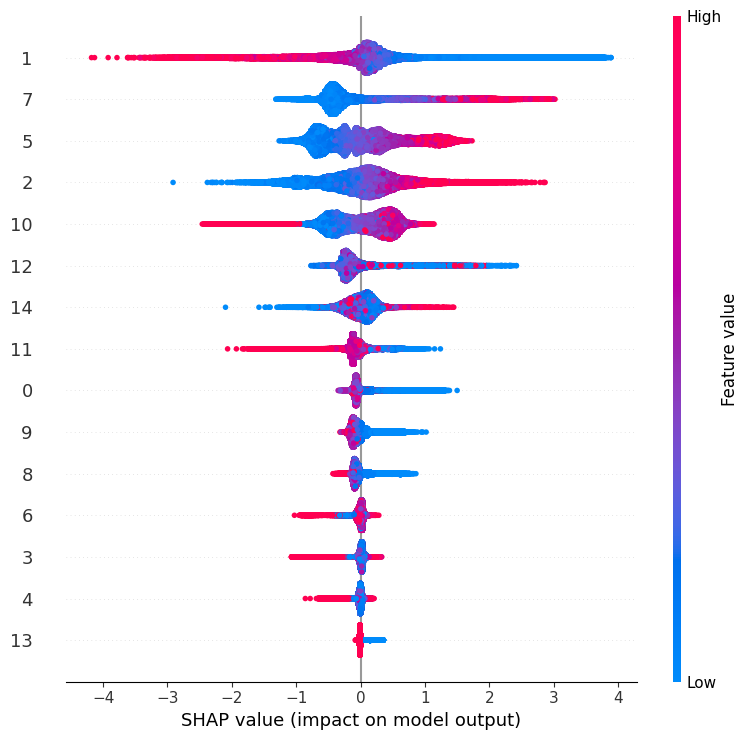

In [23]:
import shap

explainer = shap.TreeExplainer(cat_model)

shap_values = explainer.shap_values(val_features)

shap.summary_plot(shap_values, val_features)

We trained classical machine learning models on the 15 AST scalar features extracted from each code snippet.

These features capture structural characteristics of programs such as tree depth, branching patterns, and control-flow complexity.

Unlike lexical models such as TF-IDF, AST features focus on the syntactic shape of the program, enabling the model to detect structural regularities typical of machine-generated code.

This experiment evaluates whether structural programming patterns alone are sufficient for detecting machine-generated code.

AST scalar features capture high-level structural properties of programs,
such as tree depth, branching factor, and control flow complexity.

Random Forest achieved the best validation performance (F1 = 0.77),
suggesting that non-linear interactions between structural features
are important for distinguishing machine-generated code.

However, evaluation on the cross-language test set revealed a large
performance drop (F1 ≈ 0.38), indicating that structural statistics
alone are insufficient for robust cross-language generalization.